In [6]:
import numpy as np

import scipy.stats as sts

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

# 11.1

## 1.

In [2]:
Finch = [19, 14, 9, 13, 15, 12, 10, 8, 13, 12, 9, 11, 15, 11]
Holmes = [12, 6, 10, 11, 8, 12, 14, 7, 7, 9, 6, 7, 16, 9]

shapiro_finch = sts.shapiro(Finch)
shapiro_holmes = sts.shapiro(Holmes)

shapiro_finch, shapiro_holmes

(ShapiroResult(statistic=np.float64(0.9545065736573612), pvalue=np.float64(0.6325869324302887)),
 ShapiroResult(statistic=np.float64(0.9238126110029157), pvalue=np.float64(0.2493890664837905)))

$$H_0: data\, is\, normally\, distributed$$
$$H_1: data\, is\, not\, normally\, distributed$$


$$\alpha = 0.005$$

Since, Mr.Finch and Mr.Holmes p-value is larger than alpha (0.63 > 0.005) (0.25 > 0.005), we retain the H_0\
Therefore, both dataset can be treated as normally distributed

## 2.

$$H_0: \rho = 0$$
$$H_1: \rho \neq 0$$

In [3]:
rho = sts.pearsonr(Finch, Holmes)
rho

PearsonRResult(statistic=np.float64(0.3166170313873315), pvalue=np.float64(0.27006818771697383))

The correlation for sample is weak (0.32) but from p-value (0.27 > 0.05) the test is not statistically significant.\
Therefore, we retain the H_0 because insufficient of evidence

## 3.

Yes, as the the follwing reason:
- The data has been collects over the same two week period
- Both shops is next to each other
- Both sell smartphone

## 4.

We use Wilcoxon signed-rank test. Its the nonparametric alternative to the paired t-test.

In [4]:
sts.wilcoxon(Finch, Holmes, alternative='greater')

WilcoxonResult(statistic=np.float64(78.5), pvalue=np.float64(0.01039217158439347))

At $\alpha$ = 0.0100 < 0.0103 we retain H_0, since we not have enough evidence\
Therefore, we cannot conclude that Mr.Finch's shop have more visitors than Holmes's Shop

# 11.2

## 1.

In [31]:
small = [810, 820, 820, 835, 835, 835]
medium = [840, 840, 840, 845, 855, 850]
large = [785, 790, 785, 760, 760, 770]

In [32]:
sizes = (['small'] * len(small)) + (['medium'] * len(medium)) + (['large'] * len(large))
values = small + medium + large
df = pd.DataFrame({'size': sizes, 'value': values})

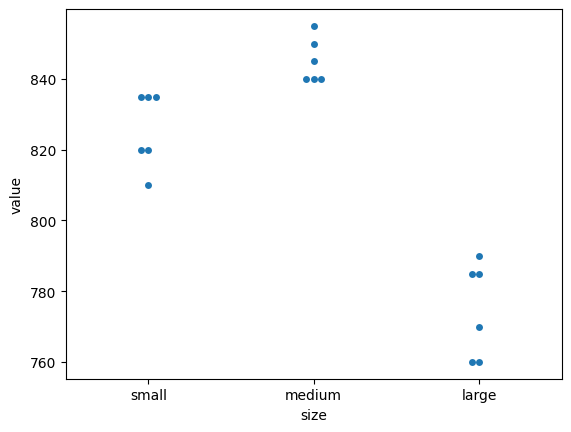

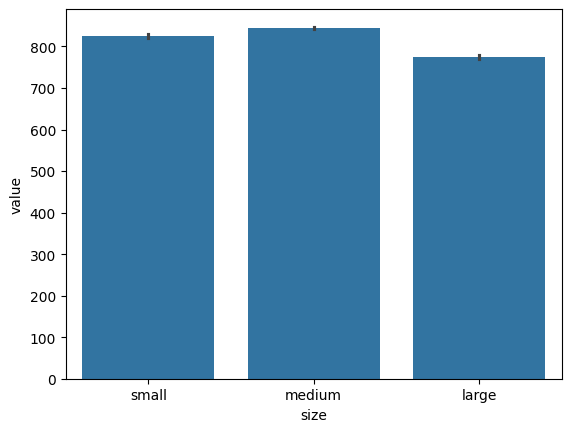

In [27]:
sns.swarmplot(x='size', y='value', data=df)
plt.show()

sns.barplot(x='size', y='value', data=df, errorbar='se')
plt.show()

In [ ]:
df.groupby('size')['value'].mean()

size
large     775.000000
medium    845.000000
small     825.833333
Name: value, dtype: float64

In [35]:
df.groupby('size')['value'].median()

size
large     777.5
medium    842.5
small     827.5
Name: value, dtype: float64

- From the swarm plot, medium vehicles appear to have the highest mean noise level and large vehicals appear to have the lowest mean noise level\
Therefore, it appears that mean noise levels differ among vehicle sizes.
- From the barplot, medium engine has the highest mean noise level and large engine has the lowest mean noise level\
Since, the SEM do not overlapped, so the mean of this 3 samples are different

$$
H_0:\ \mu_{\text{small}} = \mu_{\text{medium}} = \mu_{\text{large}}
$$

$$
H_1:\ \text{At least one mean noise level differs}
$$

## 2.

In [36]:
sts.kruskal(small, medium, large)

KruskalResult(statistic=np.float64(15.331941544885167), pvalue=np.float64(0.00046850172588372446))

At $\alpha$ = 0.05 > 0.0004 (p-value from kruskal test) we reject H_0\
Therefore, there is a difference in average noise levels between different vehicle sizes.
